In [360]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

## **Exploratory Data Analysis**

In [361]:
df = pd.read_csv("data_D.csv")
df.head()

,Unnamed: 0,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0,0x20c27,CUS_0xf64,June,NaN,32,478-73-8323,Doctor,56125.5,4875.125000,...,Standard,370.22,32.014182,28 Years and 10 Months,Yes,81.822857,182.06551022025016,High_spent_Medium_value_payments,473.62413320457887,Standard
1,1,0xc518,CUS_0x697f,March,Philh,39,367-66-5050,Entrepreneur,62148.0,NaN,...,Bad,2373.61,33.951720,16 Years and 6 Months,Yes,258.848861,195.3722153038279,High_spent_Small_value_payments,300.6789235920986,Poor
2,2,0x22663,CUS_0x7846,February,Paramadithak,45,282-14-9365,Accountant,88380.16,7471.013333,...,_,124.29,41.016763,NaN,Yes,129.723699,180.79874191787297,High_spent_Medium_value_payments,686.5788927990964,Standard
3,3,0x1ff7,CUS_0x3ef5,June,Robinsonl,32,259-09-9023,_______,7821.24,468.770000,...,Bad,2924.76,34.203026,10 Years and 2 Months,Yes,19.727923,39.93770264234067,Low_spent_Medium_value_payments,267.2113738653678,Standard
4,4,0x9a07,CUS_0x8fdf,June,Yeeo,18,312-56-4208,Scientist,107871.9,NaN,...,Standard,1005.83,27.237916,32 Years and 8 Months,No,227.241789,73.48570828760295,High_spent_Large_value_payments,820.9050026625811,Standard


In [362]:
df.tail()

,Unnamed: 0,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
24995,24995,0x1c3d4,CUS_0x2346,July,Chanu,32,918-83-4696,Accountant,58892.86_,5106.738333,...,Standard,666.0,29.716761,33 Years and 3 Months,Yes,118.348232,213.8312235074904,High_spent_Small_value_payments,438.49437811272605,Standard
24996,24996,0xa1aa,CUS_0x81e2,May,James Regang,45,662-55-6547,_______,75042.72,6484.560000,...,Standard,417.62,42.662754,17 Years and 7 Months,Yes,105.684175,80.53114128738457,High_spent_Large_value_payments,702.2406836898317,Standard
24997,24997,0x1f36,CUS_0x1d4e,May,McCranke,37,182-25-5092,Journalist,25530.33,2137.527500,...,Standard,761.18,35.252857,31 Years and 9 Months,NM,0.000000,64.22191842939257,!@9#%8,429.53083157060746,Standard
24998,24998,0x24fd8,CUS_0x1ec2,July,Rossr,21,258-93-2064,Scientist,34458.06,3142.505000,...,Bad,4404.79,37.234923,13 Years and 11 Months,NM,119.622458,__10000__,High_spent_Small_value_payments,332.42502256666165,Standard
24999,24999,0x10d0c,CUS_0x9eb2,March,Miyoungg,15,930-93-7239,Writer,19647.55,NaN,...,Standard,1207.31,39.724419,14 Years and 9 Months,Yes,82.201117,40.07765458578624,High_spent_Large_value_payments,303.55081160396765,Standard


In [363]:
df.describe()

,Unnamed: 0,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Delay_from_due_date,Num_Credit_Inquiries,Credit_Utilization_Ratio,Total_EMI_per_month
count,25000.000000,21173.000000,25000.000000,25000.000000,25000.000000,25000.000000,24503.000000,25000.000000,25000.000000
mean,12499.500000,4168.307097,16.865000,23.311840,70.358920,21.065360,26.939762,32.273187,1440.039648
std,7217.022701,3170.867622,114.767426,133.618787,458.469762,14.885855,189.253774,5.114177,8514.909613
min,0.000000,303.645417,-1.000000,0.000000,1.000000,-5.000000,0.000000,20.000000,0.000000
25%,6249.750000,1625.265833,4.000000,4.000000,8.000000,10.000000,3.000000,28.059564,29.912485
50%,12499.500000,3080.353333,6.000000,5.000000,13.000000,18.000000,6.000000,32.331522,68.781136
75%,18749.250000,5927.527500,8.000000,7.000000,20.000000,28.000000,9.000000,36.475246,160.180388
max,24999.000000,15204.633333,1794.000000,1499.000000,5789.000000,67.000000,2553.000000,49.564519,82122.000000


In [364]:
df.duplicated().sum()

np.int64(0)

In [365]:
df.shape

(25000, 29)

In [366]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                25000 non-null  int64  
 1   ID                        25000 non-null  object 
 2   Customer_ID               25000 non-null  object 
 3   Month                     25000 non-null  object 
 4   Name                      22471 non-null  object 
 5   Age                       25000 non-null  object 
 6   SSN                       25000 non-null  object 
 7   Occupation                25000 non-null  object 
 8   Annual_Income             25000 non-null  object 
 9   Monthly_Inhand_Salary     21173 non-null  float64
 10  Num_Bank_Accounts         25000 non-null  int64  
 11  Num_Credit_Card           25000 non-null  int64  
 12  Interest_Rate             25000 non-null  int64  
 13  Num_of_Loan               25000 non-null  object 
 14  Type_o

In [367]:
df.columns

Index(['Unnamed: 0', 'ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN',
       'Occupation', 'Annual_Income', 'Monthly_Inhand_Salary',
       'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan',
       'Type_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment',
       'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Credit_Mix',
       'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'Credit_Score'],
      dtype='object')

In [368]:
df.isna().sum()

Unnamed: 0                     0
ID                             0
Customer_ID                    0
Month                          0
Name                        2529
Age                            0
SSN                            0
Occupation                     0
Annual_Income                  0
Monthly_Inhand_Salary       3827
Num_Bank_Accounts              0
Num_Credit_Card                0
Interest_Rate                  0
Num_of_Loan                    0
Type_of_Loan                2880
Delay_from_due_date            0
Num_of_Delayed_Payment      1744
Changed_Credit_Limit           0
Num_Credit_Inquiries         497
Credit_Mix                     0
Outstanding_Debt               0
Credit_Utilization_Ratio       0
Credit_History_Age          2249
Payment_of_Min_Amount          0
Total_EMI_per_month            0
Amount_invested_monthly     1121
Payment_Behaviour              0
Monthly_Balance              309
Credit_Score                   0
dtype: int64

In [369]:
df[df["Monthly_Balance"].astype(str).str.contains("-", na=False)]

,Unnamed: 0,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
6212,6212,0x1ceed,CUS_0x57f3,April,Kristen Haysq,29,577-85-0830,Mechanic,60904.59,NaN,...,Standard,2441.47,29.878716,12 Years and 11 Months,Yes,61.525140,394.8939566733383,Low_spent_Small_value_payments,__-333333333333333333333333333__,Standard
6577,6577,0xc0d8,CUS_0x288d,July,Selamk,55,970-19-8342,Lawyer,30748.93,2572.410833,...,Good,860.97,40.634250,19 Years and 5 Months,No,43.727774,79.07180674947499,High_spent_Small_value_payments,__-333333333333333333333333333__,Standard
6650,6650,0x1759f,CUS_0xc06e,February,radenp,30,046-72-5387,Journalist,92114.68,7811.223333,...,Standard,820.52,39.089475,20 Years and 10 Months,Yes,54.219664,NaN,High_spent_Large_value_payments,__-333333333333333333333333333__,Standard


In [370]:
num = df.select_dtypes(exclude="object").columns
cat= df.select_dtypes(include="object").columns

print(f"Numerical columns : {list(num)}\n")
print(f"Categorical columns : {list(cat)}")

num = list(num)
num.remove('Unnamed: 0')
cat= list(cat)
for i in ['ID', 'Customer_ID', "Name", "SSN"]:
    cat.remove(i)

Numerical columns : ['Unnamed: 0', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Delay_from_due_date', 'Num_Credit_Inquiries', 'Credit_Utilization_Ratio', 'Total_EMI_per_month']

Categorical columns : ['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation', 'Annual_Income', 'Num_of_Loan', 'Type_of_Loan', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Credit_Mix', 'Outstanding_Debt', 'Credit_History_Age', 'Payment_of_Min_Amount', 'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance', 'Credit_Score']


In [371]:
for i in cat :
    print(f"{i} : {df[i].unique()}")

Month : ['June' 'March' 'February' 'January' 'July' 'April' 'May' 'August']
Age : ['32' '39' '45' '18' '28' '30' '37' '25' '21' '40' '42' '52_' '22' '43'
 '34' '20' '38' '51' '17' '52' '27' '19' '46' '33' '56' '28_' '26' '53'
 '15' '24_' '36' '31' '29' '24' '14' '23' '54' '47' '49' '41' '23_' '35'
 '16' '44' '1820' '50' '27_' '20_' '48' '44_' '55' '38_' '3651' '5975'
 '36_' '19_' '26_' '30_' '-500' '32_' '7986' '34_' '21_' '55_' '6424'
 '5123' '31_' '2341' '42_' '49_' '6799' '16_' '18_' '8567' '54_' '2175'
 '2037' '37_' '51_' '5995' '7323' '7851' '22_' '2977' '2474_' '46_' '15_'
 '7553' '39_' '43_' '14_' '40_' '359' '1515' '1695' '29_' '2084' '7886'
 '7806' '47_' '1657' '4906' '25_' '41_' '1651' '306' '1220' '2733' '50_'
 '17_' '7459' '53_' '4270' '328' '7776' '940' '774' '5717' '7223' '1787'
 '35_' '45_' '4580' '33_' '3665' '1176' '6777' '5222' '112' '2756' '581'
 '6091' '5018' '2048' '56_' '2209' '8561' '7131' '1664' '5788' '48_'
 '2821' '6074' '3441' '6378' '372' '3966' '7723_' '510

In [372]:
cat

['Month',
 'Age',
 'Occupation',
 'Annual_Income',
 'Num_of_Loan',
 'Type_of_Loan',
 'Num_of_Delayed_Payment',
 'Changed_Credit_Limit',
 'Credit_Mix',
 'Outstanding_Debt',
 'Credit_History_Age',
 'Payment_of_Min_Amount',
 'Amount_invested_monthly',
 'Payment_Behaviour',
 'Monthly_Balance',
 'Credit_Score']

In [373]:
cattonum = ["Age", 'Annual_Income',
 'Num_of_Loan', 'Num_of_Delayed_Payment',
 'Changed_Credit_Limit','Outstanding_Debt',  'Amount_invested_monthly',
 'Monthly_Balance']

In [374]:
df_model = df.copy()

In [375]:
cattonum = [
    "Age",
    "Annual_Income",
    "Num_of_Loan",
    "Num_of_Delayed_Payment",
    "Changed_Credit_Limit",
    "Outstanding_Debt",
    "Amount_invested_monthly",
    "Monthly_Balance"
]

for col in cattonum:
    df_model[col] = (
        df_model[col]
        .astype(str)
        .str.replace("_", "", regex=False)
    )
    df_model[col] = pd.to_numeric(df_model[col], errors="coerce")

### **Data Analysis**

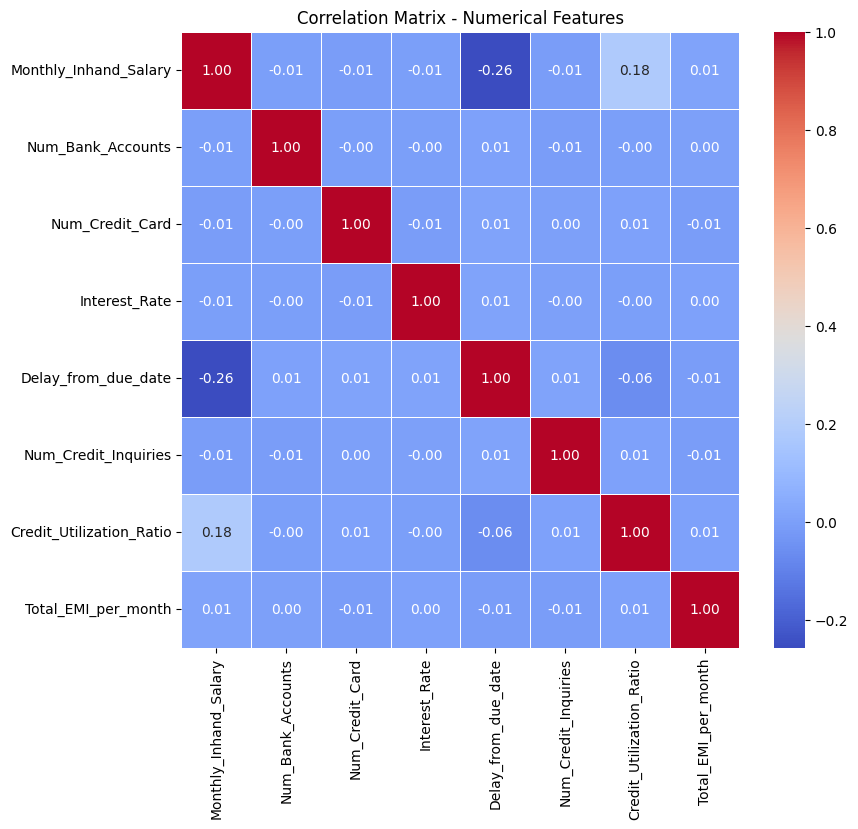

In [376]:
corr = df_model[num].corr()

plt.figure(figsize=(9,8))

sns.heatmap(
    corr,
    annot=True,        # tampilkan angka
    cmap='coolwarm',   # warna merah-biru
    fmt='.2f',
    linewidths=0.5
)

plt.title("Correlation Matrix - Numerical Features")
plt.show()

In [377]:
numeric = df_model.select_dtypes(exclude="object").columns
categoric = df_model.select_dtypes(include="object").columns

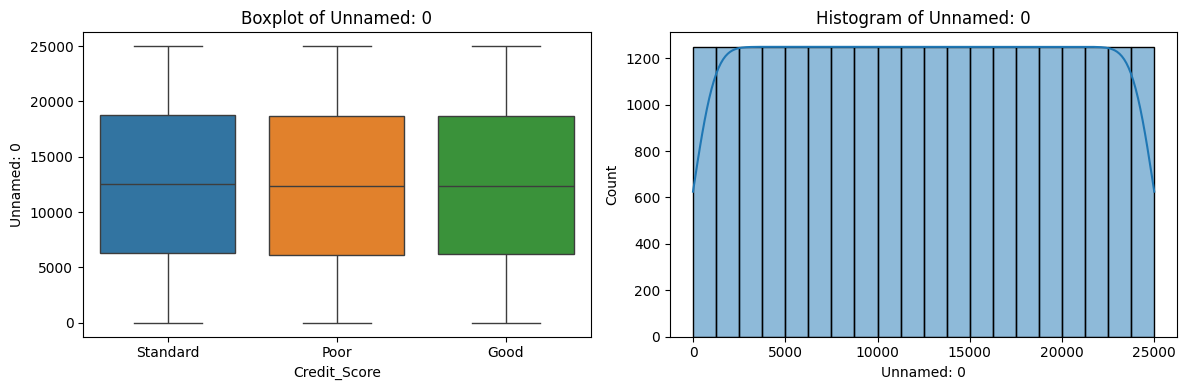

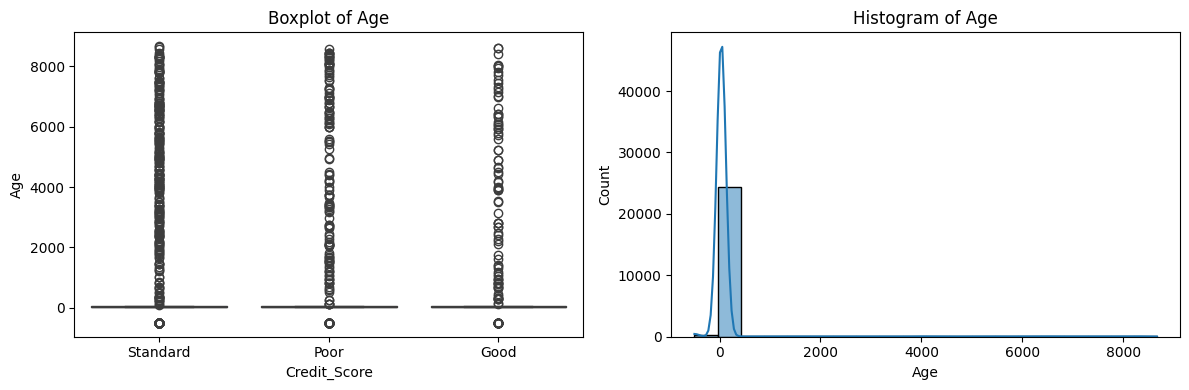

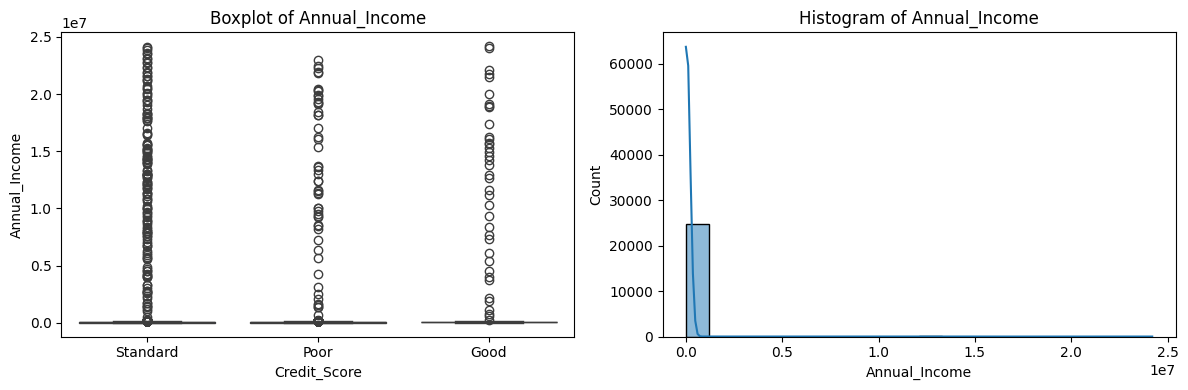

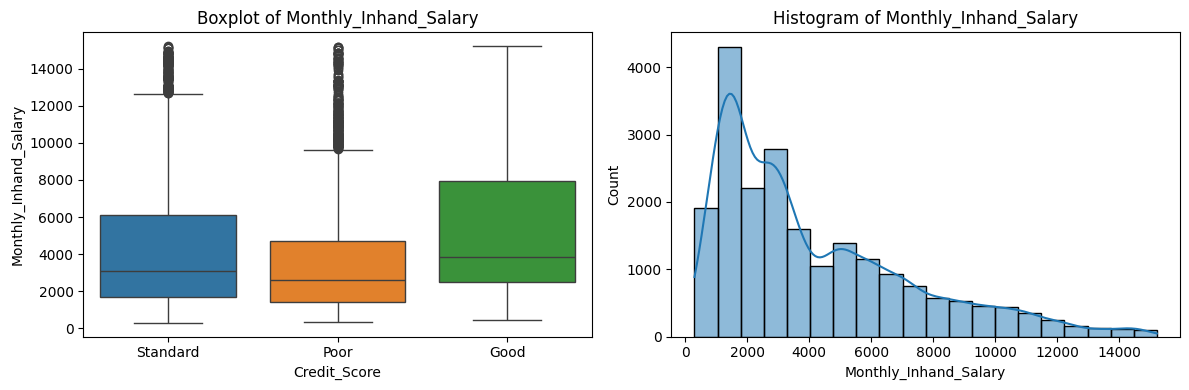

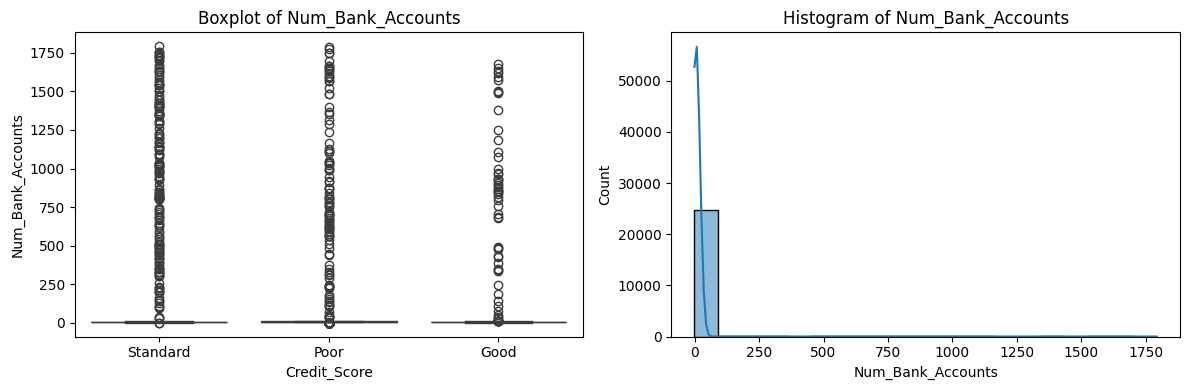

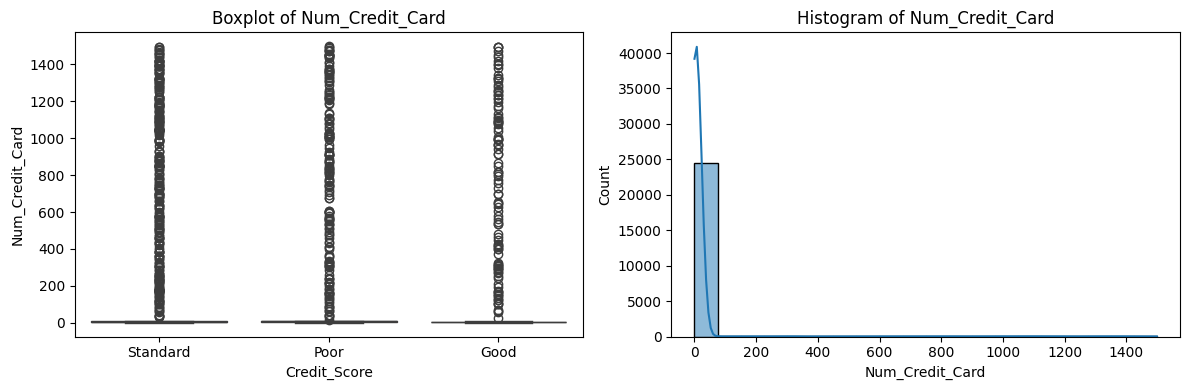

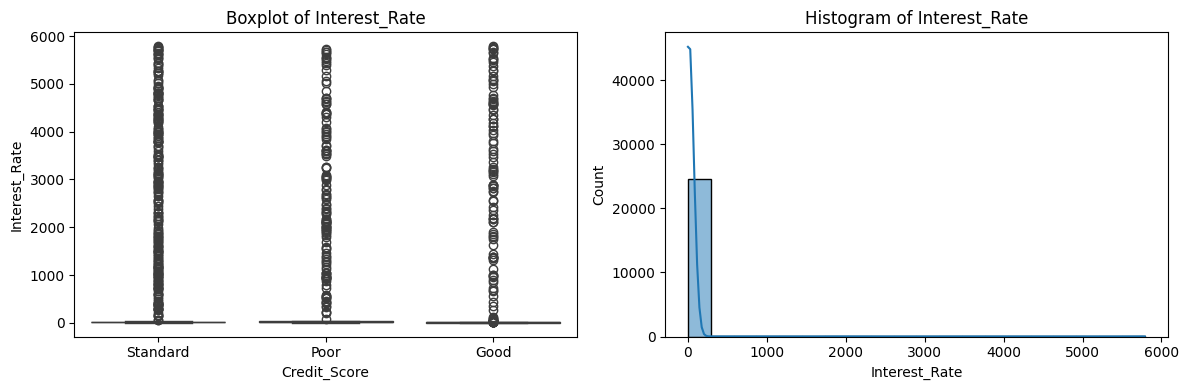

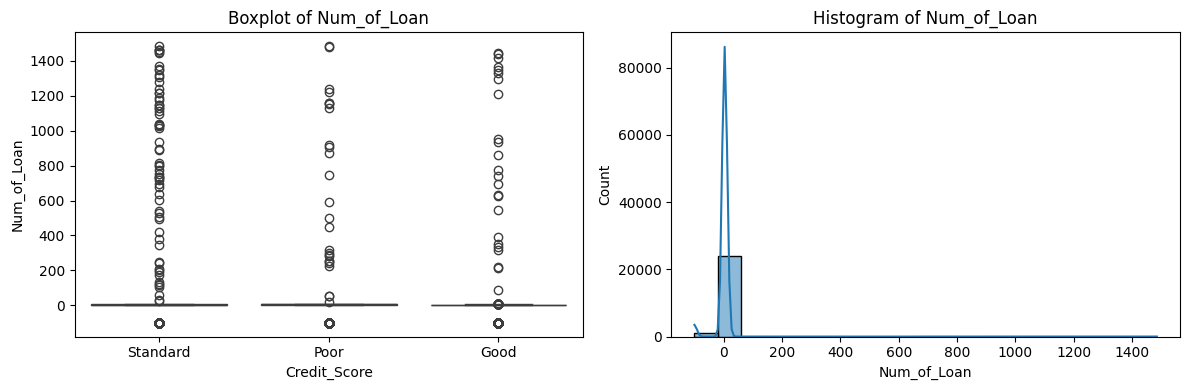

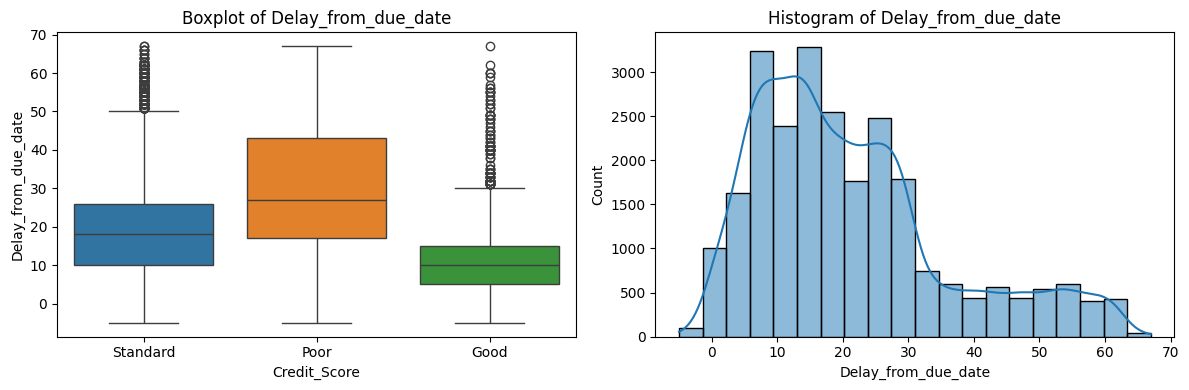

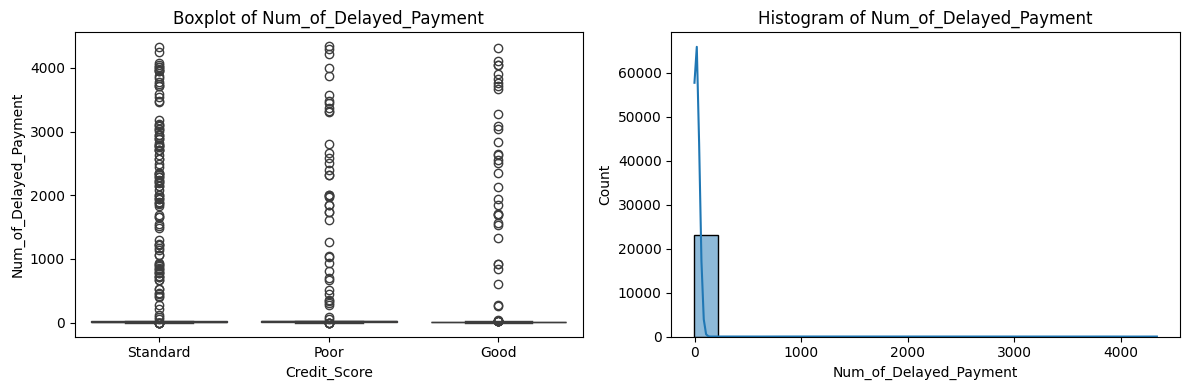

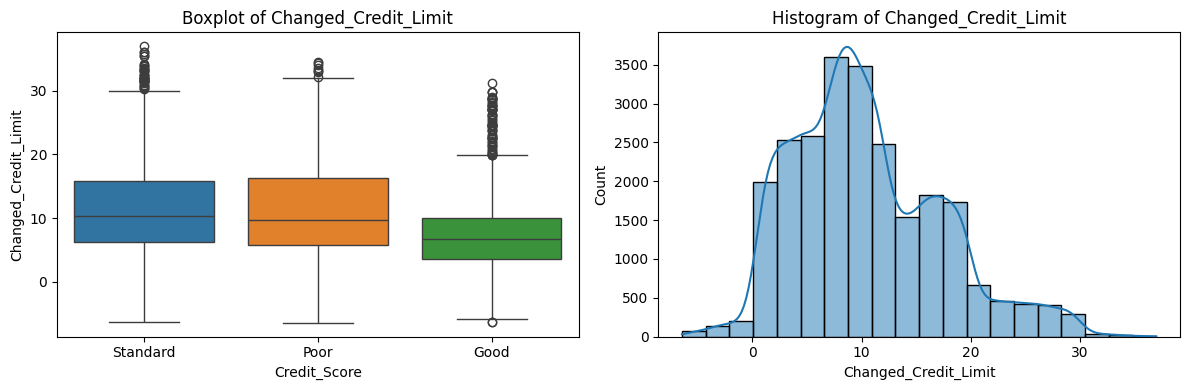

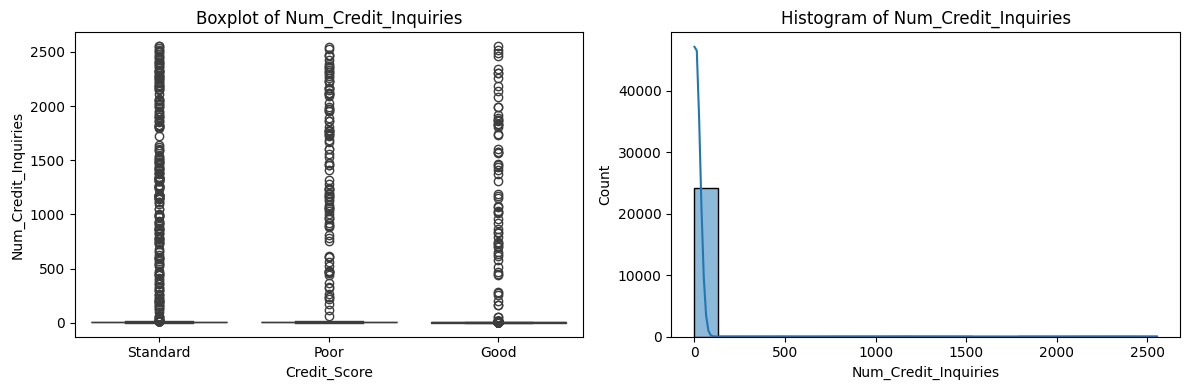

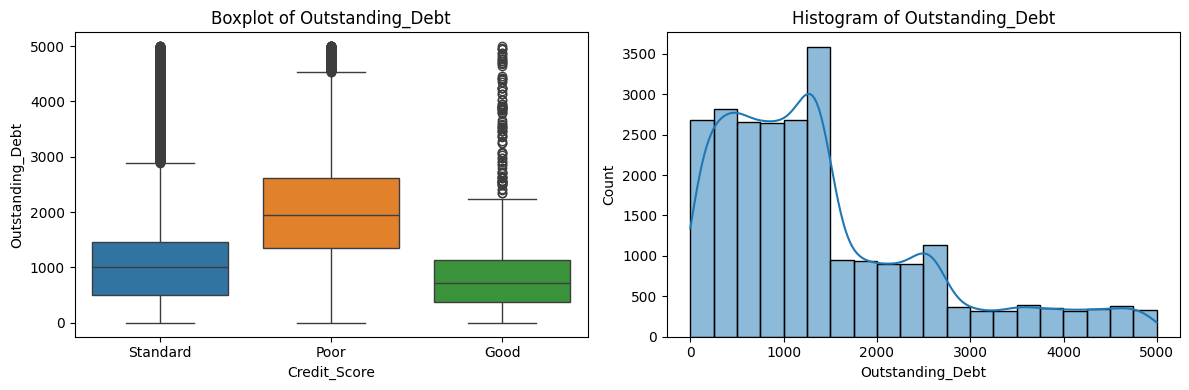

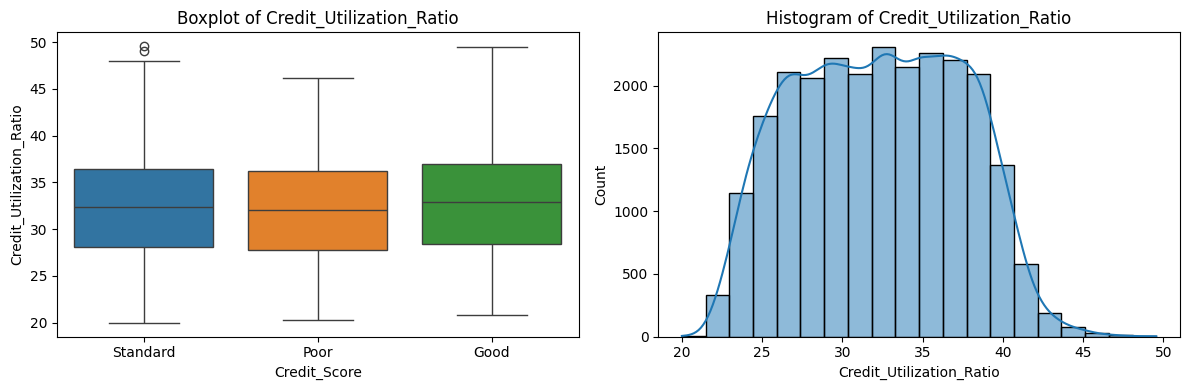

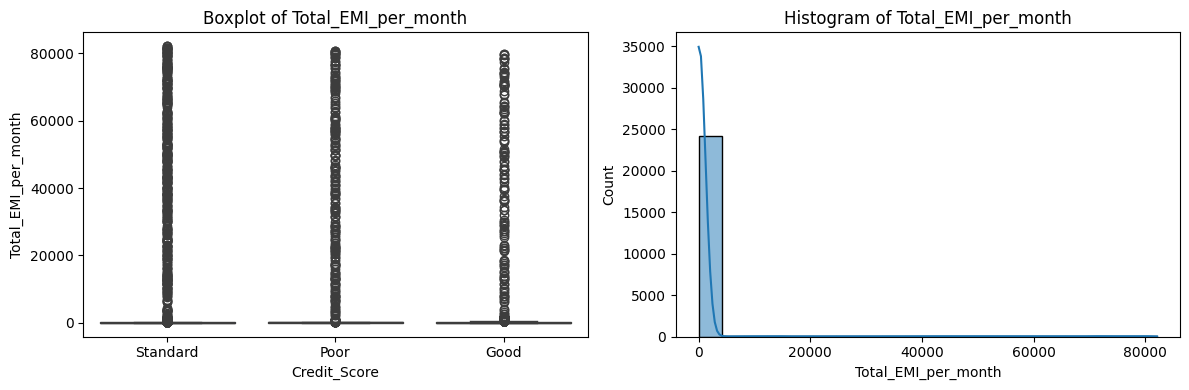

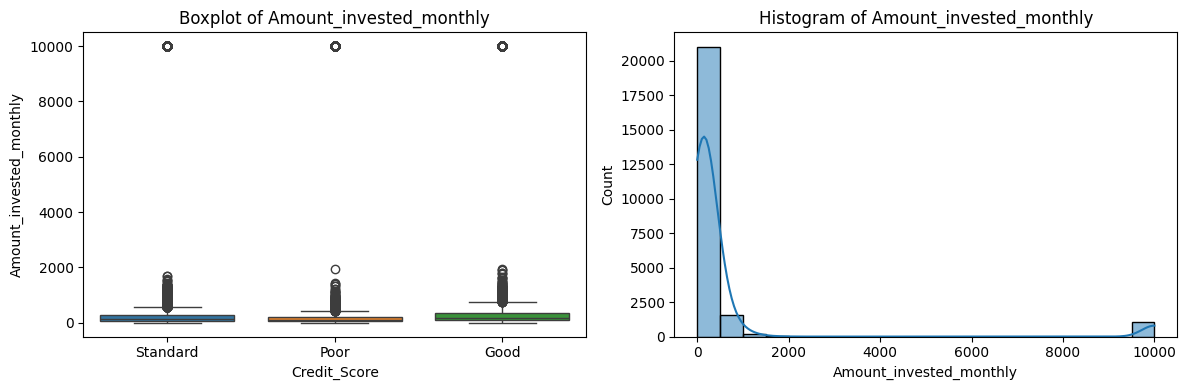

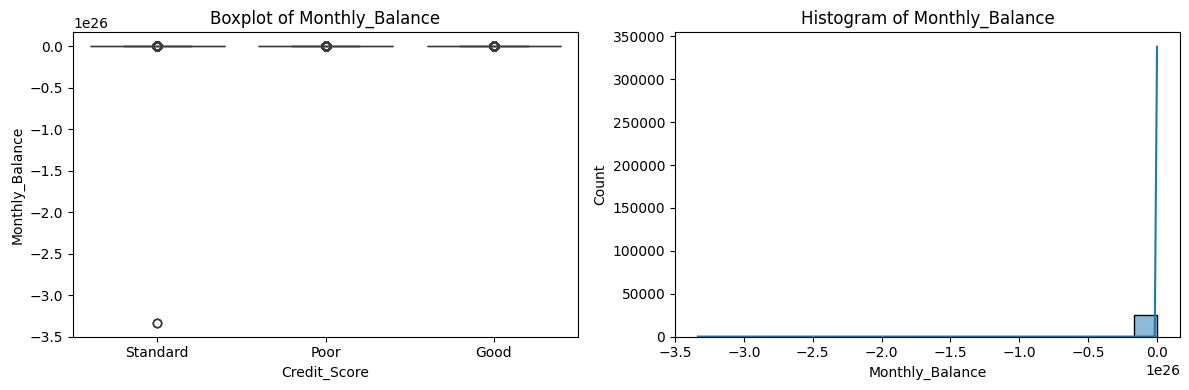

In [378]:
for i in numeric:
    fig, ax = plt.subplots(1, 2, figsize=(12,4))

    # BOX PLOT
    sns.boxplot(
        x="Credit_Score",
        y=i,
        hue="Credit_Score",
        data=df_model,
        ax=ax[0]
    )
    ax[0].set_title(f"Boxplot of {i}")

    # HISTOGRAM dengan HUE
    sns.histplot(
        data=df_model,
        x=i,
        bins=20,
        kde=True,
        ax=ax[1]
    )
    ax[1].set_title(f"Histogram of {i}")

    plt.tight_layout()
    plt.show()

In [379]:
# Ambil kolom numerik
numeric_cols = df_model.select_dtypes(include="number").columns

# Cari kolom yang memiliki nilai < 0
negative_cols = [col for col in numeric_cols if (df_model[col] < 0).any()]

print(negative_cols)

['Age', 'Num_Bank_Accounts', 'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Monthly_Balance']


#### Insight :

I found 7 columns such as ['Age', 'Num_Bank_Accounts', 'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Monthly_Balance'] having negative value. It is imposible for 'Age', 'Num_Bank_Accounts', 'Num_of_Loan' and 'Num_of_Delayed_Payment' to be negative (this should have positive value only). However, this 3 feature 'Delay_from_due_date', 'Changed_Credit_Limit' and 'Monthly_Balance' may have negative value due to customer or user conditions. I need to analyse this 3 feature more to find the issue.

In [380]:
cols = ["Delay_from_due_date", "Changed_Credit_Limit", "Monthly_Balance"]

print(df_model[cols].describe())

       Delay_from_due_date  Changed_Credit_Limit  Monthly_Balance
count         25000.000000          24477.000000     2.469100e+04
mean             21.065360             10.418801    -4.050059e+22
std              14.885855              6.802624     3.674112e+24
min              -5.000000             -6.440000    -3.333333e+26
25%              10.000000              5.380000     2.709065e+02
50%              18.000000              9.380000     3.380537e+02
75%              28.000000             14.920000     4.676070e+02
max              67.000000             36.970000     1.602041e+03


In [381]:
for col in cols:
    print(f"{col}: {(df_model[col] < 0).sum()} negative values")

Delay_from_due_date: 141 negative values
Changed_Credit_Limit: 388 negative values
Monthly_Balance: 3 negative values


In [382]:
df_model[
    (df_model["Monthly_Balance"] < 0)
]

,Unnamed: 0,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
6212,6212,0x1ceed,CUS_0x57f3,April,Kristen Haysq,29,577-85-0830,Mechanic,60904.59,NaN,...,Standard,2441.47,29.878716,12 Years and 11 Months,Yes,61.525140,394.893957,Low_spent_Small_value_payments,-3.333333e+26,Standard
6577,6577,0xc0d8,CUS_0x288d,July,Selamk,55,970-19-8342,Lawyer,30748.93,2572.410833,...,Good,860.97,40.634250,19 Years and 5 Months,No,43.727774,79.071807,High_spent_Small_value_payments,-3.333333e+26,Standard
6650,6650,0x1759f,CUS_0xc06e,February,radenp,30,046-72-5387,Journalist,92114.68,7811.223333,...,Standard,820.52,39.089475,20 Years and 10 Months,Yes,54.219664,NaN,High_spent_Large_value_payments,-3.333333e+26,Standard


In [383]:
df_model.loc[df_model["Monthly_Balance"] < 0, "Monthly_Balance"]

6212   -3.333333e+26
6577   -3.333333e+26
6650   -3.333333e+26
Name: Monthly_Balance, dtype: float64

In [384]:
df_model.loc[
    df_model["Monthly_Balance"] < 0,
    [
        "Monthly_Inhand_Salary",
        "Total_EMI_per_month",
        "Amount_invested_monthly",
        "Outstanding_Debt",
        "Monthly_Balance"
    ]
].head(20)

,Monthly_Inhand_Salary,Total_EMI_per_month,Amount_invested_monthly,Outstanding_Debt,Monthly_Balance
6212,NaN,61.525140,394.893957,2441.47,-3.333333e+26
6577,2572.410833,43.727774,79.071807,860.97,-3.333333e+26
6650,7811.223333,54.219664,NaN,820.52,-3.333333e+26


**Insight and Problem found :**
1. Numerical value as object, such as age, monthly balance,Annual_Income, Num_of_Loan,Type_of_Loan, Num_of_Delayed_Payment, Changed_Credit_Limit, Outstanding_Debt, Amount_invested_monthly **Fixed : by changing them to float** ✅
2. Missing value, either as NaN or "__ _ _" or '!@9#%8' or 'NM' or ' __ _' (in either numerical and categorical variable) **Fixed : by changing them to "unknown" or 0** ✅
3. Changing Credit History Age to year or month **Fix : by doing feature engineering**
4. Inconsistence data in number from 12 to 12_ in most of the numerical columns **Fixed : changing 12_ to 12 and turn the variable to floar or int** ✅
5. Remove SSN, Name and ID columns. ✅
6. There are 7 numeric feature with negative value. **Change Age, num_bank_accounts, num_of_loan, num_of_delayed_payment negative value** ✅
7. Found extreme value of __-333333333333___ in monthly balance, this is an error value. **Fix this value by changing it** ✅
8. Extreme outlier value ✅

# **Data Cleaning and Categoric analysis**

In [385]:
numeric = df_model.select_dtypes(exclude="object").columns
categoric = df_model.select_dtypes(include="object").columns

In [386]:
for col in categoric:
    df_model[col] = df_model[col].astype(str).str.replace("_", "", regex=False)

    # Coba ubah menjadi tipe numerik (int/float) jika memungkinkan
    try:
        df_model[col] = pd.to_numeric(df_model[col])
    except:
        pass

In [387]:
# Daftar placeholder missing value
missing_values = [np.nan, "_____", "!@9#%8", "NM", "__",""]

# Ganti placeholder menjadi NaN terlebih dahulu
df_model = df_model.replace(missing_values, np.nan)

In [388]:
numeric = df_model.select_dtypes(exclude="object").columns
categoric = df_model.select_dtypes(include="object").columns

numeric = list(numeric)
numeric.remove('Unnamed: 0')
categoric= list(categoric)
for i in ['ID', 'Customer_ID', "Name", "SSN", "Type_of_Loan", "Credit_History_Age"]:
    categoric.remove(i)

print(f"Numerical columns : {list(numeric)}\n")
print(f"Categorical columns : {list(categoric)}")

Numerical columns : ['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance']

Categorical columns : ['Month', 'Occupation', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour', 'Credit_Score']


In [389]:
# 1. Pastikan Num_of_Loan dikonversi ke numerik (dan null diubah ke NaN)
df_model['Num_of_Loan'] = pd.to_numeric(df_model['Num_of_Loan'], errors='coerce')
    
# 2. Fungsi untuk menghitung jumlah jenis pinjaman dari teks Type_of_Loan
def count_loans(text):
    if pd.isna(text) or str(text).strip().lower() in ['unknown', '', 'nan']:
        return 0 # Jika Type_of_Loan juga kosong/unknown, set ke 0 dulu sementara
    # Menghitung jumlah kategori yang dipisahkan oleh koma
    return len([item for item in str(text).split(',') if item.strip()])

# 3. Buat kolom temporary berisi hasil perhitungan dari Type_of_Loan
calculated_loans = df_model['Type_of_Loan'].apply(count_loans)
    
# 4. Isi hanya baris yang Num_of_Loan nya Kosong (NaN) menggunakan nilai hasil hitungan
df_model['Num_of_Loan'] = df_model['Num_of_Loan'].fillna(calculated_loans)
    
# 5. Jika setelah diisi masih ada sisa yang NaN (karena Type_of_Loan-nya juga kosong), 
# baru kita isi dengan median sebagai jaring pengaman terakhir.
median_val = df_model['Num_of_Loan'].median()
df_model['Num_of_Loan'] = df_model['Num_of_Loan'].fillna(median_val)

In [390]:
# Isi missing value pada kolom numerik dengan 0
# Income per month
df_model["Monthly_Inhand_Salary"] = df_model["Annual_Income"] / 12
df_model[numeric] = df_model[numeric].fillna(0)

# Isi missing value pada kolom kategorikal dengan "unknown"
df_model[categoric] = df_model[categoric].fillna("unknown")

In [391]:
# fix error value in monthly_balance
mask = df_model["Monthly_Balance"] < -1e20

df_model.loc[mask, "Monthly_Balance"] = (
    df_model.loc[mask, "Monthly_Inhand_Salary"]
    - df_model.loc[mask, "Total_EMI_per_month"]
    - df_model.loc[mask, "Amount_invested_monthly"]
)

In [392]:
df_model.loc[mask, "Monthly_Balance"] 

6212    4618.963404
6577    2439.611253
6650    7622.003669
Name: Monthly_Balance, dtype: float64

In [393]:
df_model["Occupation"].__contains__("_")

False

In [394]:
col_neg = ['Age', 'Num_Bank_Accounts', 'Num_of_Loan', 'Num_of_Delayed_Payment']

for col in col_neg:
    if col in df_model.columns:
        df_model[col] = df_model[col].clip(lower=0)

print("✅ Nilai negatif pada kolom target berhasil diubah menjadi positif.")

✅ Nilai negatif pada kolom target berhasil diubah menjadi positif.


In [395]:
# Fixing outlier value using winsorizing
numerical_cols = df_model.select_dtypes(include=[np.number]).columns.tolist()

# 3. Singkirkan kolom identitas/indeks yang tidak perlu dibersihkan outlier-nya
# Contoh: membuang kolom urutan nomor bawan pandas 'Unnamed: 0'
exclude_cols = ['Unnamed: 0']
numerical_cols = [col for col in numerical_cols if col not in exclude_cols]

print(colom_yang_diproses := f"Memproses {len(numerical_cols)} kolom numerik...")

# 4. Lakukan looping Winsorizing (Batas bawah 5% dan batas atas 95%)
for col in numerical_cols:
    lower_limit = df_model[col].quantile(0.05)  # Batas bawah percentile ke-5
    upper_limit = df_model[col].quantile(0.95)  # Batas atas percentile ke-95
    
    # Buat kolom baru dengan akhiran '_winsorized' agar data asli tidak hilang
    df_model[f'{col}'] = df_model[col].clip(lower_limit, upper_limit)

print("✅ Proses Winsorizing selesai untuk semua kolom numerik!\n")

Memproses 16 kolom numerik...
✅ Proses Winsorizing selesai untuk semua kolom numerik!



### **Categoric Data Analysis**

**_Menggunakan t-test untuk mencari corelasi antara kategorik dengan kategorik_**

In [396]:
from scipy.stats import chi2_contingency

In [397]:
for col in categoric:
    if col != 'Credit_Score':
        ct = pd.crosstab(df_model[col], df_model['Credit_Score'])
        chi2, p, dof, exp = chi2_contingency(ct)
        print(f"{col}: p-value = {p}")

Month: p-value = 4.302797215222117e-09
Occupation: p-value = 0.00018820840486743684
Credit_Mix: p-value = 0.0
Payment_of_Min_Amount: p-value = 0.0
Payment_Behaviour: p-value = 5.826365275469591e-68


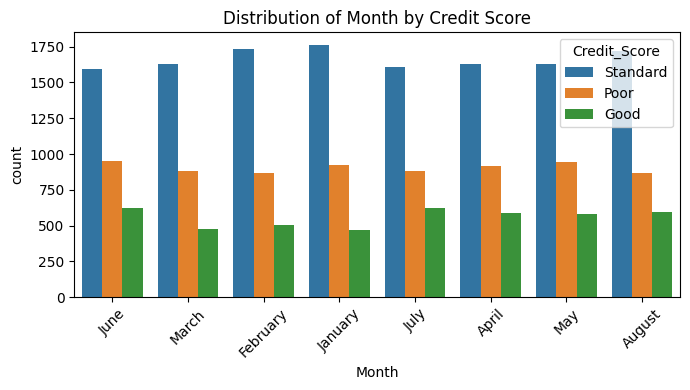

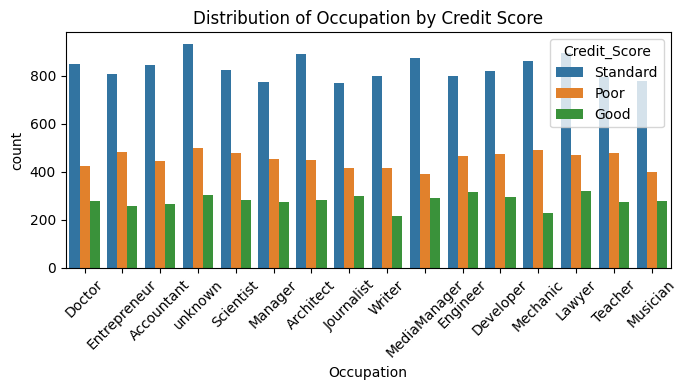

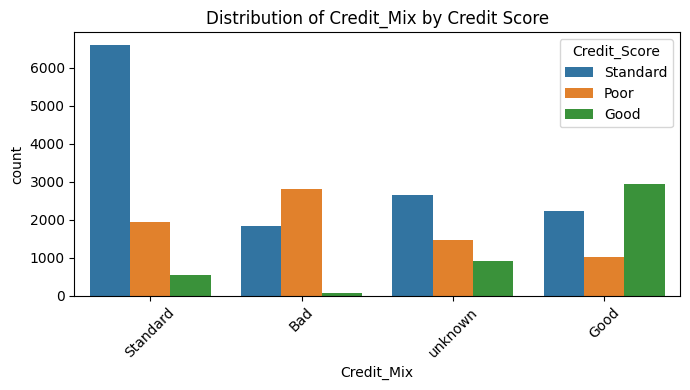

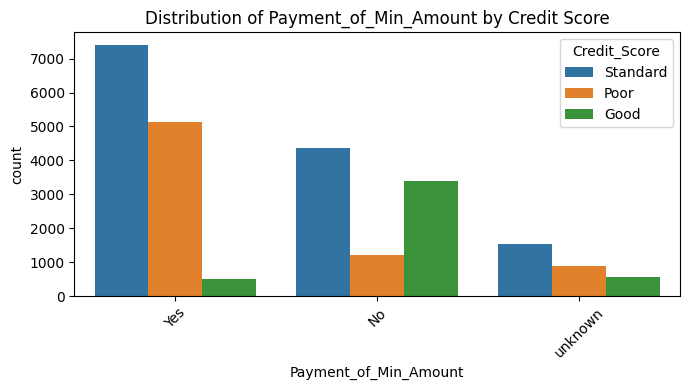

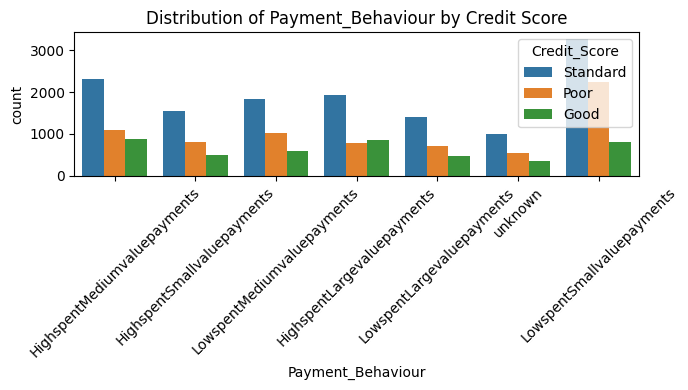

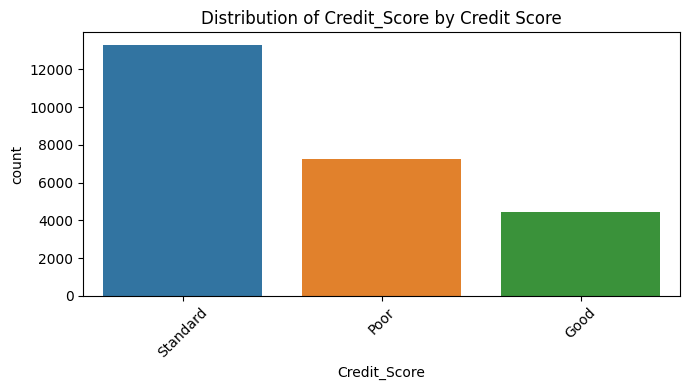

In [398]:
for i in categoric:
    plt.figure(figsize=(7,4))
    
    sns.countplot(
        x=f'{i}',
        hue='Credit_Score',
        data=df_model
    )
    
    plt.title(f"Distribution of {i} by Credit Score")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## **Feature Engineering**

In [399]:
# Ekstrak tahun dan bulan
years = df_model["Credit_History_Age"].str.extract(r"(\d+)\s+Years")[0].astype(float)
months = df_model["Credit_History_Age"].str.extract(r"(\d+)\s+Months")[0].astype(float)

# Konversi menjadi total bulan
df_model["Credit_History_Age_Months"] = years * 12 + months

In [400]:
df_model["Credit_History_Age_Months"]=df_model["Credit_History_Age_Months"].fillna(0)

In [401]:
# Hindari pembagian dengan nol
eps = 1e-6

# Debt to Income Ratio
df_model["Debt_to_Income_Ratio"] = (
    df_model["Outstanding_Debt"] / (df_model["Annual_Income"] + eps)
)

# Income to EMI Ratio
df_model["Income_to_EMI_Ratio"] = (
    df_model["Monthly_Inhand_Salary"] / (df_model["Total_EMI_per_month"] + eps)
)

# Savings Ratio
df_model["Savings_Ratio"] = (
    df_model["Amount_invested_monthly"] / (df_model["Monthly_Inhand_Salary"] + eps)
)

# Remaining money after EMI
df_model["Remaining_Money"] = (
    df_model["Monthly_Inhand_Salary"] - df_model["Total_EMI_per_month"]
)

# Delayed payments per loan
df_model["Delayed_Payment_Ratio"] = (
    df_model["Num_of_Delayed_Payment"] / (df_model["Num_of_Loan"] + eps)
)

# Credit inquiries per loan
df_model["Inquiry_per_Loan"] = (
    df_model["Num_Credit_Inquiries"] / (df_model["Num_of_Loan"] + eps)
)

In [403]:
for i in categoric :
    print(f"{i} : {df_model[i].unique()}")

Month : ['June' 'March' 'February' 'January' 'July' 'April' 'May' 'August']
Occupation : ['Doctor' 'Entrepreneur' 'Accountant' 'unknown' 'Scientist' 'Manager'
 'Architect' 'Journalist' 'Writer' 'MediaManager' 'Engineer' 'Developer'
 'Mechanic' 'Lawyer' 'Teacher' 'Musician']
Credit_Mix : ['Standard' 'Bad' 'unknown' 'Good']
Payment_of_Min_Amount : ['Yes' 'No' 'unknown']
Payment_Behaviour : ['HighspentMediumvaluepayments' 'HighspentSmallvaluepayments'
 'LowspentMediumvaluepayments' 'HighspentLargevaluepayments'
 'LowspentLargevaluepayments' 'unknown' 'LowspentSmallvaluepayments']
Credit_Score : ['Standard' 'Poor' 'Good']


In [404]:
column_rem = ["Unnamed: 0",'ID', 'Customer_ID', "Name", "SSN", "Type_of_Loan", "Credit_History_Age"]

df_model = df_model.drop(columns= column_rem)

In [405]:
cols = [
    'Month', 'Occupation', 'Credit_Mix',
    'Payment_of_Min_Amount', 'Payment_Behaviour',
    'Credit_Score'
]

for col in cols:
    df_model[col] = df_model[col].astype(str).str.strip()

In [406]:
month_mapping = {
    'January': 1,
    'February': 2,
    'March': 3,
    'April': 4,
    'May': 5,
    'June': 6,
    'July': 7,
    'August': 8
}

occupation_mapping = {
    'unknown': -1,
    'Accountant': 0,
    'Architect': 1,
    'Developer': 2,
    'Doctor': 3,
    'Engineer': 4,
    'Entrepreneur': 5,
    'Journalist': 6,
    'Lawyer': 7,
    'Manager': 8,
    'Mechanic': 9,
    'MediaManager': 10,
    'Musician': 11,
    'Scientist': 12,
    'Teacher': 13,
    'Writer': 14
}

credit_mix_mapping = {
    'Bad': 0,
    'Standard': 1,
    'Good': 2,
    'unknown': -1
}

payment_min_mapping = {
    'No': 0,
    'Yes': 1,
    'unknown': -1
}

payment_behaviour_mapping = {
    'LowspentSmallvaluepayments': 0,
    'LowspentMediumvaluepayments': 1,
    'LowspentLargevaluepayments': 2,
    'HighspentSmallvaluepayments': 3,
    'HighspentMediumvaluepayments': 4,
    'HighspentLargevaluepayments': 5,
    'unknown': -1
}

credit_score_mapping = {
    'Poor': 0,
    'Standard': 1,
    'Good': 2
}

df_model['Month'] = df_model['Month'].map(month_mapping)
df_model['Occupation'] = df_model['Occupation'].map(occupation_mapping)
df_model['Credit_Mix'] = df_model['Credit_Mix'].map(credit_mix_mapping)
df_model['Payment_of_Min_Amount'] = df_model['Payment_of_Min_Amount'].map(payment_min_mapping)
df_model['Payment_Behaviour'] = df_model['Payment_Behaviour'].map(payment_behaviour_mapping)
df_model['Credit_Score'] = df_model['Credit_Score'].map(credit_score_mapping)

In [407]:
X = df_model.drop("Credit_Score", axis = 1)
y = df_model["Credit_Score"]

In [408]:
# Berasumsi 'X' adalah fitur-fitur dan 'y' adalah target (Good, Standard, Bad)
# stratify=y memastikan proporsi kelas di data train dan test tetap sama
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y
)

print(f"Jumlah data Training: {X_train.shape[0]}")
print(f"Jumlah data Testing: {X_test.shape[0]}")

Jumlah data Training: 20000
Jumlah data Testing: 5000


In [409]:
scaler = StandardScaler()

X_train[numeric] = scaler.fit_transform(X_train[numeric])
X_test[numeric] = scaler.transform(X_test[numeric])

# **Modeling**

In [410]:
# Logistic Regression sensitif terhadap skala data, jadi wajib pakai StandardScaler
model_lr = make_pipeline(
    LogisticRegression(C= 0.316735, max_iter=1000, random_state=42)
)

# Training
model_lr.fit(X_train, y_train)

y_pred_lr = model_lr.predict(X_test)

In [411]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=15,
    min_samples_split=5
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [412]:
dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2
)

# Training
dt_model.fit(X_train, y_train)

# Prediksi
y_pred_dt = dt_model.predict(X_test)

# **Evaluation**

In [413]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr, target_names= ["Poor", "Standard", "Good"]))

Logistic Regression Accuracy: 0.5318
              precision    recall  f1-score   support

        Poor       0.20      0.00      0.00      1446
    Standard       0.53      1.00      0.69      2661
        Good       0.60      0.01      0.01       893

    accuracy                           0.53      5000
   macro avg       0.44      0.33      0.24      5000
weighted avg       0.45      0.53      0.37      5000



In [414]:
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf, target_names= ["Poor", "Standard", "Good"]))

Random Forest Accuracy: 0.718
              precision    recall  f1-score   support

        Poor       0.74      0.70      0.72      1446
    Standard       0.75      0.76      0.76      2661
        Good       0.59      0.64      0.61       893

    accuracy                           0.72      5000
   macro avg       0.69      0.70      0.70      5000
weighted avg       0.72      0.72      0.72      5000



In [415]:
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt, target_names= ["Poor", "Standard", "Good"]))

Decision Tree Accuracy: 0.6808
              precision    recall  f1-score   support

        Poor       0.69      0.62      0.66      1446
    Standard       0.73      0.72      0.72      2661
        Good       0.54      0.66      0.60       893

    accuracy                           0.68      5000
   macro avg       0.66      0.67      0.66      5000
weighted avg       0.69      0.68      0.68      5000



### Insight :

Pada model yang sudah saya buat, saya mengutamakan f1 score. Hal ini saya lakukan karena, semua kelas yang diprediksi (kelas : standard, poor dan good) memiliki tingkat kepentingan yang sama rata. Model yang baik harus dapat melakukan prediksi secara tepat antara kelas good, poor maupun standard. (prediksi yang seimbang ketepatannya pada semua kelas). Saya memilih Random forest karena memiliki tingkat f1 score yang tinggi dibandingkan dengan model decision tree dan logistic regression dengan f1 score 0.61 untuk kelas good, 0.76 untuk kelas standard, dan 0.72 untuk kelas poor. (Dengan data test yang tidak seimbang maka akurasi f1 score dapat dinyatakan sudah baik).